In [1]:

import numpy as np 
import matplotlib.pyplot as plt
import glob
import cv2
from keras.models import Model, Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from keras.layers.experimental import SyncBatchNormalization
import os
import seaborn as sns

In [2]:
SIZE = 256
batch_size = 32
channels = 3

In [3]:
train_images = []
train_labels = [] 
for directory_path in glob.glob("../MRI_DATASET/Training*"):
    label = directory_path.split("\\")[-1]
    print(label)
    for img_path in glob.glob(os.path.join(directory_path, "*.jpg")):
        print(img_path)
        img = cv2.imread(img_path, cv2.IMREAD_COLOR)       
        img = cv2.resize(img, (SIZE, SIZE))
        img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
        train_images.append(img)
        train_labels.append(label)
        
train_images = np.array(train_images)
train_labels = np.array(train_labels)

Training


In [4]:
pth = os.listdir('../MRI_DATASET/Training/')
classes = {'notumor':0, 'pituitary':1, 'meningioma':2 , 'glioma':3}

In [5]:
train_images = []
train_labels = []

for cls in classes:
    class_path = os.path.join(pth, cls)
    for j in os.listdir(class_path):
        img_path = os.path.join(class_path, j)
        
        # Check if the file is an image by its extension
        if not j.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')):
            print(f"Skipping non-image file: {img_path}")
            continue
        
        img = cv2.imread(img_path, 0)
        
        if img is not None:
            try:
                img = cv2.resize(img, (256, 256))
                
                # Verify the shape of the image
                if img.shape != (256, 256):
                    print(f"Skipping image with incorrect shape: {img_path}, shape: {img.shape}")
                    continue
                
                X.append(img)
                Y.append(classes[cls])
            except Exception as e:
                print(f"Error resizing image {img_path}: {e}")
        else:
            print(f"Warning: Could not load image {img_path}")

# Debugging: Check for any elements with incorrect shape in X
for idx, img in enumerate(X):
    if img.shape != (256, 256):
        print(f"Incorrect shape found at index {idx}: {img.shape}")

# Convert lists to numpy arrays
try:
    X = np.array(X)
    Y = np.array(Y)
    print(f"Successfully converted to numpy arrays. Shape of X: {X.shape}, Shape of Y: {Y.shape}")
except ValueError as ve:
    print(f"Error converting to numpy arrays: {ve}")

# Flatten the images if necessary
if isinstance(X, np.ndarray) and len(X) > 0:
    X_updated = X.reshape(len(X), -1)
    print(f"Shape of X_updated: {X_updated.shape}")
else:
    print("X is not a numpy array or is empty.")

TypeError: expected str, bytes or os.PathLike object, not list

In [4]:
class_names = train_ds.class_names
class_names

['glioma', 'meningioma', 'notumor', 'pituitary']

In [5]:
len(train_ds)

219

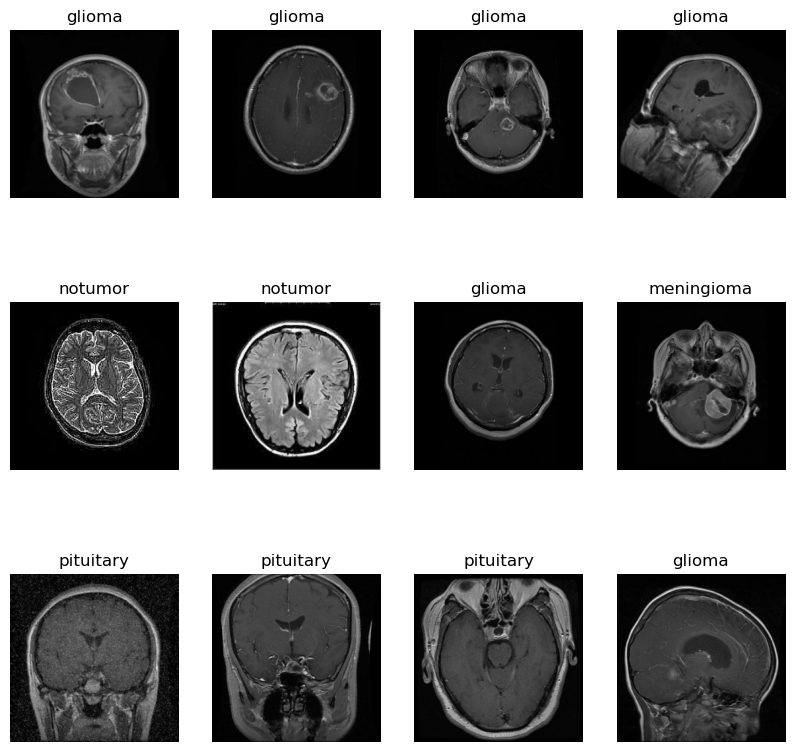

In [6]:
plt.figure(figsize=(10,10))
for image_batch, label_batch in train_ds.take(1):
    for i in range (12):
        ax = plt.subplot(3,4,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]])
        plt.axis('off')

In [7]:
len(train_ds)

219

In [8]:
# Split the training dataset into training and validation sets
train_size = int(0.9 * len(train_ds))
train_img = train_ds.take(train_size)
val_ds = train_ds.skip(train_size)

In [9]:
print(len(train_img))
print(len(val_ds))

197
22


In [10]:
train_img = train_img.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_img = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [11]:
resize_and_rescale = tf.keras.Sequential([
    layers.experimental.preprocessing.Resizing(image_size,image_size),
    layers.experimental.preprocessing.Rescaling(1.0/255)
])

In [12]:
input_shape = (batch_size,image_size,image_size,channels)
n_classes = 4

In [13]:
model = models.Sequential([
    resize_and_rescale,
    #data_augmentation,
    layers.Conv2D(32, (3,3),activation='relu',input_shape = input_shape),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(n_classes,activation='softmax')
    
])

model.build(input_shape=input_shape)

In [14]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (32, 256, 256, 3)         0         
                                                                 
 conv2d (Conv2D)             (32, 254, 254, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2  (32, 127, 127, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (32, 125, 125, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (32, 62, 62, 64)          0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (32, 60, 60, 64)         

In [15]:
model.compile(
    optimizer='adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics = ['accuracy']
)

In [16]:
history = model.fit(
    train_img,
    epochs=800,
    batch_size=batch_size,
    verbose=1,
    validation_data=val_img

)

Epoch 1/20


197/197 [==============================] - 406s 2s/step - loss: 0.6945 - accuracy: 0.7183 - val_loss: 0.4779 - val_accuracy: 0.8206
Epoch 2/20
197/197 [==============================] - 378s 2s/step - loss: 0.3992 - accuracy: 0.8530 - val_loss: 0.3819 - val_accuracy: 0.8632
Epoch 3/20
197/197 [==============================] - 358s 2s/step - loss: 0.2397 - accuracy: 0.9134 - val_loss: 0.2977 - val_accuracy: 0.8926
Epoch 4/20
197/197 [==============================] - 446s 2s/step - loss: 0.1336 - accuracy: 0.9521 - val_loss: 0.2957 - val_accuracy: 0.9191
Epoch 5/20
197/197 [==============================] - 362s 2s/step - loss: 0.0784 - accuracy: 0.9730 - val_loss: 0.2776 - val_accuracy: 0.9132
Epoch 6/20
197/197 [==============================] - 360s 2s/step - loss: 0.0480 - accuracy: 0.9841 - val_loss: 0.2420 - val_accuracy: 0.9309
Epoch 7/20
197/197 [==============================] - 377s 2s/step - loss: 0.0421 - accuracy: 0.9849 - val_loss: 0.2838 - val_accuracy: 0.93

In [17]:
scores = model.evaluate(test_ds)

65/65 [==============================] - 32s 366ms/step - loss: 0.5539 - accuracy: 0.9118


In [1]:
y_pred = model.predict(test_ds)

NameError: name 'model' is not defined

In [18]:
scores

[0.5539180636405945, 0.91177898645401]

In [19]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

In [20]:
ephocs = 10

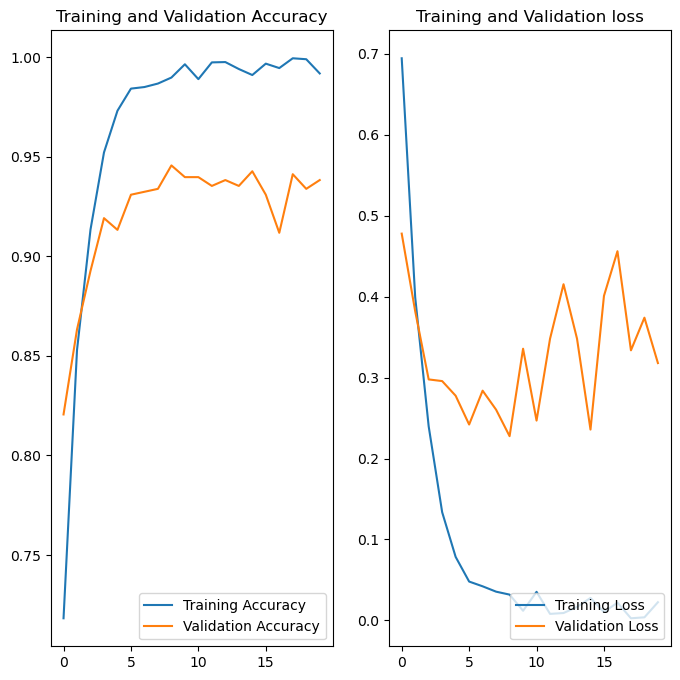

In [21]:
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(range(ephocs),acc,label = "Training Accuracy")
plt.plot(range(ephocs),val_acc,label = "Validation Accuracy")
plt.legend(loc='lower right')
plt.title("Training and Validation Accuracy")

plt.subplot(1,2,2)
plt.plot(range(ephocs),loss,label = "Training Loss")
plt.plot(range(ephocs),val_loss,label = "Validation Loss")
plt.legend(loc='lower right')
plt.title("Training and Validation loss")

plt.show()

First image to Predict
actual label: pituitary
1/1 [==============================] - 0s 482ms/step
pituitary


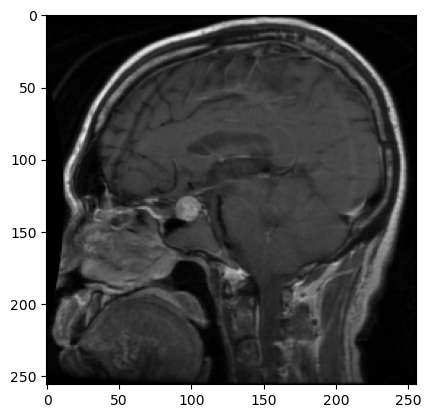

In [34]:
for image_batch,label_batch in test_ds.take(1):
    first_image = image_batch[0].numpy().astype('uint8')
    first_label = label_batch[0].numpy()
    print("First image to Predict")
    plt.imshow(first_image)
    print("actual label:",class_names[first_label])
    
    batch_prediction = model.predict(image_batch)
    print(class_names[np.argmax(batch_prediction[0])])

In [27]:
def predict(model,img):
    img_array = tf.keras.preprocessing.image.img_to_array(image[i].numpy())
    img_array = tf.expand_dims(img_array,0)
    
    prediction = model.predict(img_array)
    
    predicted_class = class_names[np.argmax(prediction[0])]
    confidence = round(100 * (np.max(prediction[0])),2)
    return predicted_class, confidence

1/1 [==============================] - 0s 34ms/step


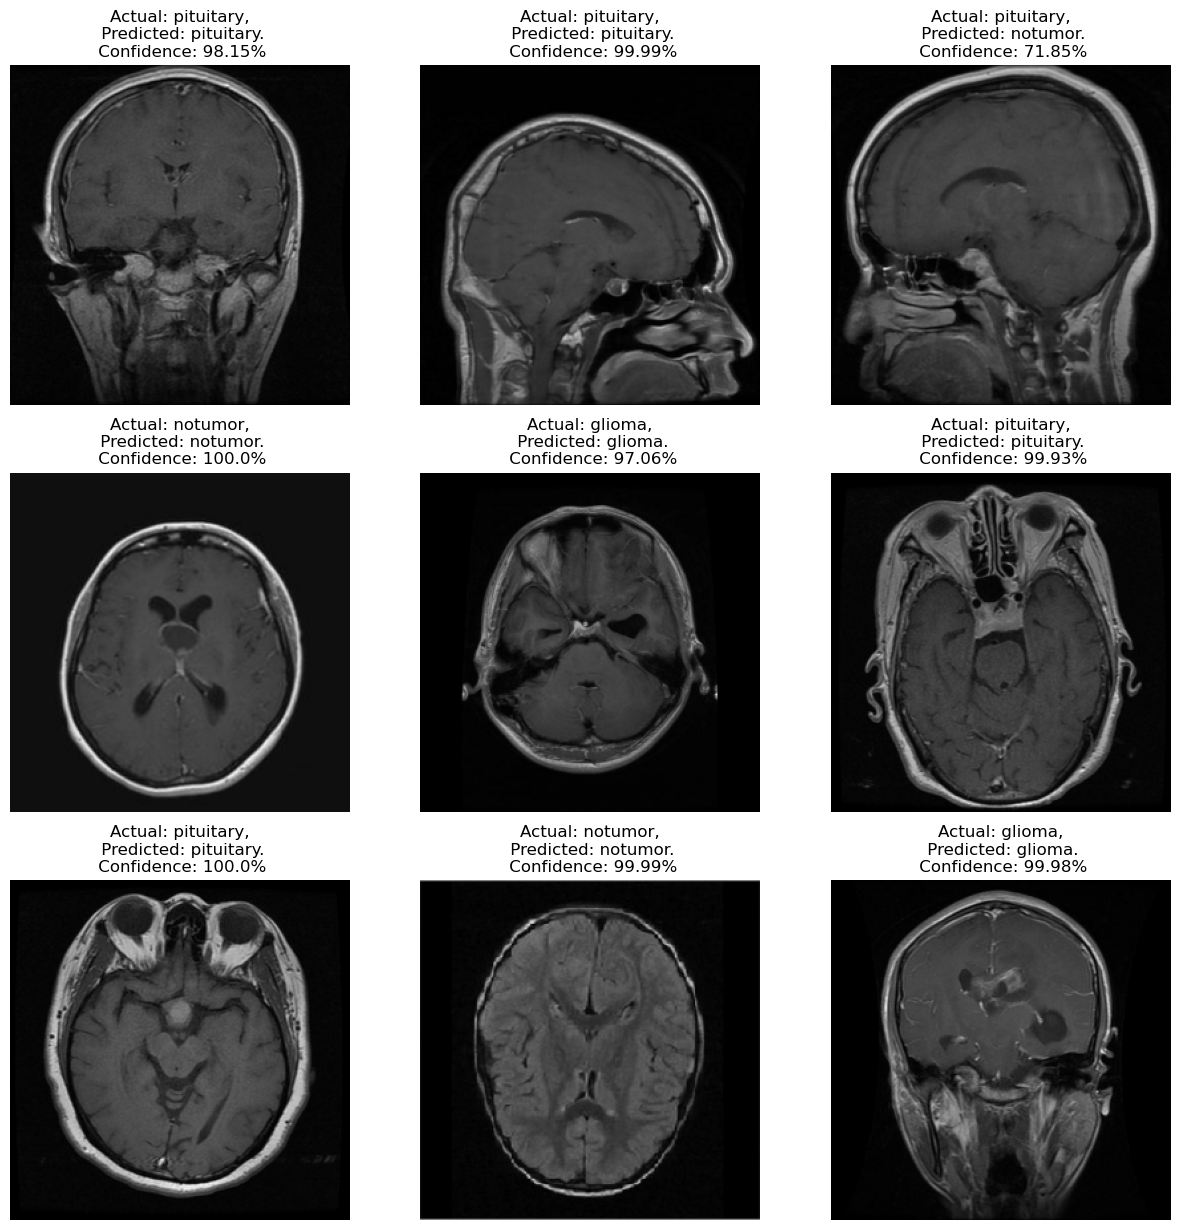

In [24]:
plt.figure(figsize=(15,15))
for image, labels in test_ds.take(1):
    for i in range (9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(image[i].numpy().astype('uint8'))
        
        predicted_class, confidence = predict(model,image[i].numpy())
        actual_class = class_names[labels[i]]
        
        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")
        
        plt.axis('off')
        

In [35]:
model_version=1
model.save(f"../CNN_model/models/{model_version}")

INFO:tensorflow:Assets written to: ../CNN_model/models/1\assets


INFO:tensorflow:Assets written to: ../CNN_model/models/1\assets


In [ ]:
import pickle

In [ ]:
import os
import pickle
os.makedirs("../MODELS", exist_ok=True)
filename = "../MODELS/MRI_model.sav"
pickle.dump(model, open(filename, "wb"))
print("Saved:", filename)